In [98]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [99]:
FILTERED_VCF = "Z:/PRJ-NeoTrio_2021/RNAseq/RNA_variant_calling/filtered_vcfs"

## Get BRAF V600 mutations from VCFs

In [100]:

def get_v600_status(vcf_dir=FILTERED_VCF):
    """Detect BRAF V600E/K/R from filtered VCFs using coordinate-based logic,
    extracting VAF from AD field and depth info."""

    timepoint_map = {
        "PRE": "Baseline",
        "ED1": "Week 1",
        "ED2": "Week 2",
        "CLND": "Week 6",
        "PRO": "Progressed",
        "PROG": "Progressed",
    }
    tp_order = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

    V600_CHROM = "chr7"
    V600_POS_336 = 140753336
    V600_POS_337 = 140753337

    results = []

    for vcf_path in sorted(glob.glob(os.path.join(vcf_dir, "*.filtered.vcf"))):
        filename = os.path.basename(vcf_path)

        timepoint = "Unknown"
        patient_id = filename
        match = re.match(r"^(\d+)(CLND|PROG|PRO|PRE|ED1|ED2)", filename, re.IGNORECASE)
        if match:
            patient_id = match.group(1)
            tp_key = match.group(2).upper()
            timepoint = timepoint_map.get(tp_key, "Unknown")

        v600_variants = {}
        with open(vcf_path) as f:
            for line in f:
                if line.startswith("#"):
                    continue
                fields = line.strip().split("\t")
                chrom = fields[0]
                pos = int(fields[1])
                filt = fields[6]
                if chrom == V600_CHROM and pos in (V600_POS_336, V600_POS_337) and filt == "PASS":
                    v600_variants[pos] = fields

        if V600_POS_336 in v600_variants:
            fields_336 = v600_variants[V600_POS_336]
            ref_336 = fields_336[3]
            alt_336 = fields_336[4]

            # Case 1: MNV record
            if ref_336 == "AC":
                if alt_336 == "TT":
                    v600_type = "V600K"
                elif alt_336 == "CT":
                    v600_type = "V600R"
                else:
                    v600_type = f"V600_unknown({ref_336}>{alt_336})"

            # Case 2: Single-base REF at 336
            elif ref_336 == "A":
                if V600_POS_337 in v600_variants:
                    fields_337 = v600_variants[V600_POS_337]
                    alt_337 = fields_337[4]
                    combined_alt = alt_336 + alt_337

                    if combined_alt == "TT":
                        v600_type = "V600K"
                    elif combined_alt == "CT":
                        v600_type = "V600R"
                    else:
                        v600_type = f"V600_unknown(AC>{combined_alt})"

                    ref_336 = "AC"
                    alt_336 = combined_alt

                elif alt_336 == "T":
                    v600_type = "V600E"
                else:
                    v600_type = f"V600_unknown({ref_336}>{alt_336})"
            else:
                v600_type = f"V600_unknown({ref_336}>{alt_336})"

            # Extract VAF from AD field
            vaf, ref_reads, alt_reads, dp = extract_vaf_dp(v600_variants[V600_POS_336])

            # For split dinucleotide, use position with higher depth
            if v600_type in ("V600K", "V600R") and V600_POS_337 in v600_variants:
                vaf_337, ref_337, alt_337, dp_337 = extract_vaf_dp(v600_variants[V600_POS_337])
                if dp_337 is not None and dp is not None and dp_337 > dp:
                    vaf, ref_reads, alt_reads, dp = vaf_337, ref_337, alt_337, dp_337

            results.append({
                "PATIENT": patient_id,
                "TIMEPOINT": timepoint,
                "REF": ref_336,
                "ALT": alt_336,
                "V600_TYPE": v600_type,
                "VAF": vaf,
                "REF_READS": ref_reads,
                "ALT_READS": alt_reads,
                "DP": dp,
                "QUAL": float(fields_336[5]) if fields_336[5] != "." else None,
                "FILTER": fields_336[6],
                "POS": V600_POS_336,
            })
        else:
            results.append({
                "PATIENT": patient_id,
                "TIMEPOINT": timepoint,
                "REF": None,
                "ALT": None,
                "V600_TYPE": "WT",
                "VAF": 0.0,
                "REF_READS": None,
                "ALT_READS": None,
                "DP": None,
                "QUAL": None,
                "FILTER": None,
                "POS": None,
            })

    df = pd.DataFrame(results)
    df["TIMEPOINT"] = pd.Categorical(
        df["TIMEPOINT"], categories=tp_order, ordered=True
    )
    df = df.sort_values(["TIMEPOINT", "PATIENT"]).reset_index(drop=True)

    for tp in tp_order:
        sub = df[df["TIMEPOINT"] == tp]
        if sub.empty:
            continue
        v600e = (sub["V600_TYPE"] == "V600E").sum()
        v600k = (sub["V600_TYPE"] == "V600K").sum()
        v600r = (sub["V600_TYPE"] == "V600R").sum()
        wt = (sub["V600_TYPE"] == "WT").sum()
        pos_vaf = sub.loc[sub["VAF"] > 0, "VAF"]
        median_vaf = pos_vaf.median() if len(pos_vaf) > 0 else None
        print(
            f"{tp} — V600E: {v600e} | V600K: {v600k} | V600R: {v600r} | WT: {wt} "
            f"| Total: {sub['PATIENT'].nunique()} "
            f"| Median VAF: {median_vaf:.3f}" if median_vaf is not None else
            f"{tp} — V600E: {v600e} | V600K: {v600k} | V600R: {v600r} | WT: {wt} "
            f"| Total: {sub['PATIENT'].nunique()} | Median VAF: N/A"
        )

    return df

def extract_vaf_dp(fields):
    """Parse AD and DP from VCF FORMAT and SAMPLE columns."""
    format_keys = fields[8].split(":")
    sample_values = fields[9].split(":")
    fmt = dict(zip(format_keys, sample_values))

    vaf = None
    ref_reads = None
    alt_reads = None
    dp = None

    if "AD" in fmt:
        ad = fmt["AD"].split(",")
        try:
            ref_reads = int(ad[0])
            alt_reads = int(ad[1])
            total = ref_reads + alt_reads
            ### calculate vaf = alt reads / total reads 
            vaf = alt_reads / total if total > 0 else None
        except (ValueError, IndexError):
            pass

    if "DP" in fmt:
        try:
            dp = int(fmt["DP"])
        except ValueError:
            pass

    return vaf, ref_reads, alt_reads, dp

In [101]:
### run v600 fx from fitlered vcf dir
v600_df = get_v600_status()
v600_df

Baseline — V600E: 35 | V600K: 5 | V600R: 2 | WT: 14 | Total: 56 | Median VAF: 0.600
Week 1 — V600E: 33 | V600K: 3 | V600R: 1 | WT: 18 | Total: 55 | Median VAF: 0.500
Week 2 — V600E: 28 | V600K: 3 | V600R: 0 | WT: 26 | Total: 57 | Median VAF: 0.469
Week 6 — V600E: 15 | V600K: 2 | V600R: 0 | WT: 33 | Total: 50 | Median VAF: 0.467
Progressed — V600E: 3 | V600K: 1 | V600R: 0 | WT: 1 | Total: 5 | Median VAF: 0.708


,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,VAF,REF_READS,ALT_READS,DP,QUAL,FILTER,POS
0,16518,Baseline,A,T,V600E,0.218750,25.0,7.0,32.0,133.64,PASS,140753336.0
1,18369,Baseline,A,T,V600E,0.604651,17.0,26.0,43.0,744.64,PASS,140753336.0
2,24799,Baseline,A,T,V600E,0.458333,26.0,22.0,48.0,519.64,PASS,140753336.0
3,28248,Baseline,A,T,V600E,0.814815,5.0,22.0,27.0,619.64,PASS,140753336.0
4,36029,Baseline,A,T,V600E,0.266667,22.0,8.0,30.0,179.64,PASS,140753336.0
...,...,...,...,...,...,...,...,...,...,...,...,...
218,28248,Progressed,A,T,V600E,0.852941,5.0,29.0,34.0,920.64,PASS,140753336.0
219,43463,Progressed,A,T,V600E,0.467742,33.0,29.0,62.0,946.64,PASS,140753336.0
220,51685,Progressed,AC,TT,V600K,0.659574,16.0,31.0,47.0,1246.64,PASS,140753336.0
221,53620,Progressed,None,None,WT,0.000000,NaN,NaN,NaN,NaN,None,NaN


In [102]:
dna_meta = pd.read_excel("z:/PRJ-NeoTrio_2021/DNAseq/Sequenza/sequenza_braf_vaf.xlsx")

In [103]:
dna_meta

,Unnamed: 0,sample_id,cellularity,ploidy,SLPP,n_solutions,n_segments,pass_purity_20_sequenza,batch,join_key,vcf_file,sample_full,maf_number,melpin,maf_file,tmb_count,tmb_per_mbp,braf_v600_AF,purity_est_perc,pass_purity_20perc_th_vaf
0,0,37747PRE-37747-1,0.81,2.1,0.986397,3,121,PASS,Batch_1,37747PRE-37747-1,37747PRE-37747-1_g.hard-filtered.vcf,37747PRE-37747-1_g.hard-filtered,6,37747PRE,6.vep.maf,162,3.24,0.638554,127.710843,Yes
1,1,43306PRE-43306-1,0.10,2.3,0.162976,1,145,FAIL,Batch_1,43306PRE-43306-1,43306PRE-43306-1_g.hard-filtered.vcf,43306PRE-43306-1_g.hard-filtered,8,43306PRE,8.vep.maf,488,9.76,0.166667,33.333333,Yes
2,2,47711PRE-47711-1,0.12,1.8,0.149732,3,124,FAIL,Batch_1,47711PRE-47711-1,47711PRE-47711-1_g.hard-filtered.vcf,47711PRE-47711-1_g.hard-filtered,13,47711PRE,13.vep.maf,164,3.28,0.175258,35.051546,Yes
3,3,18369PRE-18369-1,0.15,2.0,0.089357,4,104,FAIL,Batch_1,18369PRE-18369-1,18369PRE-18369-1_g.hard-filtered.vcf,18369PRE-18369-1_g.hard-filtered,2,18369PRE,2.vep.maf,515,10.30,0.411290,82.258065,Yes
4,4,48234PRE-48234-1,0.64,2.3,0.650946,4,136,PASS,Batch_1,48234PRE-48234-1,48234PRE-48234-1_g.hard-filtered.vcf,48234PRE-48234-1_g.hard-filtered,15,48234PRE,15.vep.maf,188,3.76,0.414141,82.828283,Yes
5,7,24799PRE-24799-1,0.79,2.0,0.775446,3,177,PASS,Batch_1,24799PRE-24799-1,24799PRE-24799-1_g.hard-filtered.vcf,24799PRE-24799-1_g.hard-filtered,3,24799PRE,3.vep.maf,110,2.20,0.423529,84.705882,Yes
6,8,43463PRE-43463-1,0.85,2.9,0.876219,4,174,PASS,Batch_1,43463PRE-43463-1,43463PRE-43463-1_g.hard-filtered.vcf,43463PRE-43463-1_g.hard-filtered,9,43463PRE,9.vep.maf,52,1.04,0.511111,102.222222,Yes
7,9,28248PRE-28248-1,0.61,2.1,0.512812,3,184,PASS,Batch_1,28248PRE-28248-1,28248PRE-28248-1_g.hard-filtered.vcf,28248PRE-28248-1_g.hard-filtered,4,28248PRE,4.vep.maf,667,13.34,0.627907,125.581395,Yes
8,10,16518PRE-16518-2,0.29,1.7,0.186244,3,149,PASS,Batch_1,16518PRE-16518-2,16518PRE-16518-2_g.hard-filtered.vcf,16518PRE-16518-2_g.hard-filtered,1,16518PRE,1.vep.maf,340,6.80,0.266667,53.333333,Yes
9,12,48210CLND-48210-1,0.10,2.0,0.073870,3,151,FAIL,Batch_1,48210CLND-48210-1,48210CLND-48210-1_g.hard-filtered.vcf,48210CLND-48210-1_g.hard-filtered,14,48210CLND,14.vep.maf,675,13.50,0.117647,23.529412,Yes


In [104]:
rna_meta = pd.read_csv("z:\PRJ-NeoTrio_2021\RNAseq\counts_rna_meta_full.csv")
rna_meta

,Unnamed: 0,MelPin,DOB,GENDER,Nodal.Basin,V600,PROG.Pre.Sx,PROG.Post.Sx,ARM,Timepoint,pCR..Y...1..N...0.,path.response..1.pCR.2.npCR.3.pPR.4.pNR.,Major.Path.Response..pCR.npCR.1.pPR.pNR.0.,Any.Response..pCR.npCR.PR...1..NR.0.,Suffix,clinical_mapping
0,1,9999_S0,8/01/1968,F,AXILLA,E,0.0,N,CON,0,0,3,0,1,_S0,PRE
1,2,9999_S1,8/01/1968,F,AXILLA,E,0.0,N,CON,1,0,3,0,1,_S1,ED1
2,3,9999_S2,8/01/1968,F,AXILLA,E,0.0,N,CON,2,0,3,0,1,_S2,ED2
3,4,9999_S3,8/01/1968,F,AXILLA,E,0.0,N,CON,3,0,3,0,1,_S3,CLND
4,5,16518_S0,1959-06-12,M,GROIN,E,0.0,Y,CON,0,0,4,0,0,_S0,PRE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,219,43463_S4,1955-08-31,M,GROIN,E,0.0,Y,SEQ,4,0,4,0,0,_S4,PROG
219,220,53620_S4,1976-04-26,M,GROIN,K,0.0,Y,ALONE,4,0,3,0,1,_S4,PROG
220,221,55314_S4,1981-12-08,M,GROIN,E,NaN,Y,SEQ,4,0,4,0,0,_S4,PROG
221,222,50861_S2,1958-07-25,M,NECK,E,0.0,Y,ALONE,2,0,4,0,0,_S0,PRE


In [105]:
# Drop old merge artifacts
v600_df = v600_df[[c for c in v600_df.columns if not c.endswith(("_x", "_y"))]]

# Reload and clean meta
rna_meta["MelPin"] = rna_meta["MelPin"].astype(str).str.replace(r"_S\d+$", "", regex=True)

# Verify the fix
print("meta MelPin samples:", rna_meta["MelPin"].unique()[:5])

patient_meta = rna_meta.drop_duplicates(subset="MelPin").set_index("MelPin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

any_resp_map = {1: "Responder", 0: "Non-responder"}
patient_meta["AnyResponse"] = patient_meta["Any.Response..pCR.npCR.PR...1..NR.0."].map(any_resp_map)

v600_df = v600_df.merge(
    patient_meta[["Response", "MPR", "AnyResponse", "ARM"]].reset_index().rename(columns={"MelPin": "PATIENT"}),
    on="PATIENT",
    how="left",
)

v600_df

meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,VAF,REF_READS,ALT_READS,DP,QUAL,FILTER,POS,Response,MPR,AnyResponse,ARM
0,16518,Baseline,A,T,V600E,0.218750,25.0,7.0,32.0,133.64,PASS,140753336.0,pNR,NMPR,Non-responder,CON
1,18369,Baseline,A,T,V600E,0.604651,17.0,26.0,43.0,744.64,PASS,140753336.0,pCR,MPR,Responder,CON
2,24799,Baseline,A,T,V600E,0.458333,26.0,22.0,48.0,519.64,PASS,140753336.0,pNR,NMPR,Non-responder,CON
3,28248,Baseline,A,T,V600E,0.814815,5.0,22.0,27.0,619.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
4,36029,Baseline,A,T,V600E,0.266667,22.0,8.0,30.0,179.64,PASS,140753336.0,pCR,MPR,Responder,CON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,28248,Progressed,A,T,V600E,0.852941,5.0,29.0,34.0,920.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
219,43463,Progressed,A,T,V600E,0.467742,33.0,29.0,62.0,946.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
220,51685,Progressed,AC,TT,V600K,0.659574,16.0,31.0,47.0,1246.64,PASS,140753336.0,pPR,NMPR,Responder,CON
221,53620,Progressed,None,None,WT,0.000000,NaN,NaN,NaN,NaN,None,NaN,pPR,NMPR,Responder,ALONE


In [106]:
v600_df[v600_df["PATIENT"] == "53540"]

,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,VAF,REF_READS,ALT_READS,DP,QUAL,FILTER,POS,Response,MPR,AnyResponse,ARM
42,53540,Baseline,AC,TT,V600K,0.595745,19.0,28.0,47.0,1111.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
96,53540,Week 1,AC,TT,V600K,0.166667,30.0,6.0,36.0,154.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
153,53540,Week 2,AC,TT,V600K,0.171429,29.0,6.0,35.0,157.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
206,53540,Week 6,AC,TT,V600K,0.566038,23.0,30.0,53.0,1182.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ


In [107]:
print("v600_df PATIENT samples:", v600_df["PATIENT"].unique()[:5])
print("meta MelPin samples:", rna_meta["MelPin"].unique()[:5])

v600_df PATIENT samples: ['16518' '18369' '24799' '28248' '36029']
meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


## Generate BRAF Binary Mapping

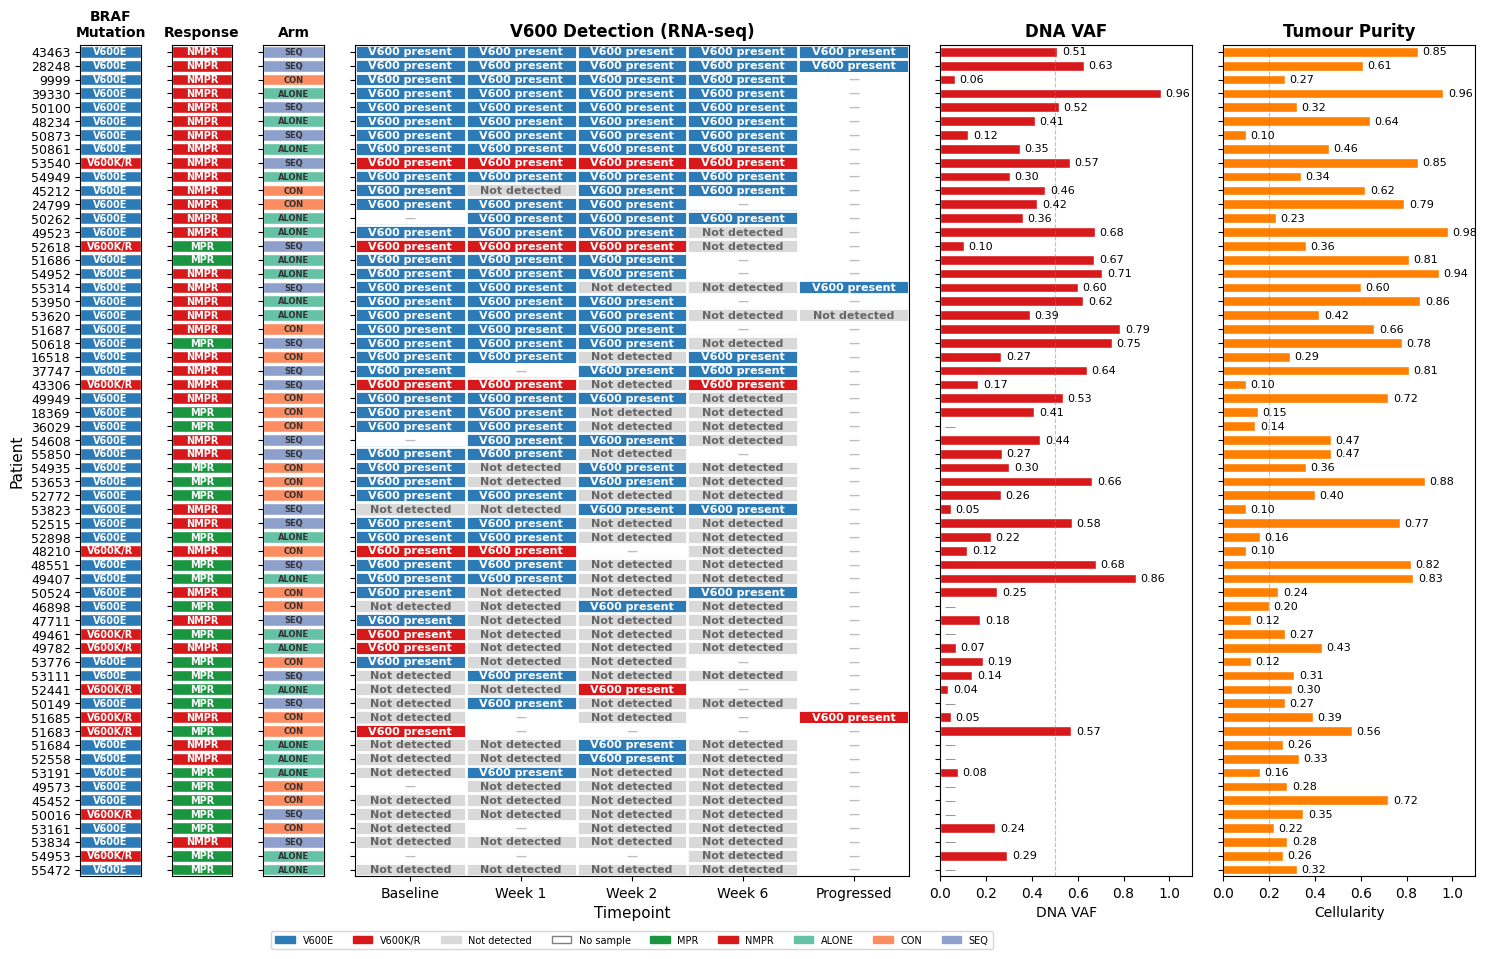

In [108]:
# --- Load data ---
rna = v600_df.copy()
braf_status = pd.read_csv("braf_status.csv")

# --- Clean patient ID ---
rna['PATIENT'] = rna['PATIENT'].astype(str).str.extract(r'(\d+)').astype(int)

# --- Merge clinical metadata ---
meta = rna_meta
meta["MelPin"] = meta["MelPin"].astype(str).str.replace(r"_S\d+$", "", regex=True).astype(int)
patient_meta = meta.drop_duplicates(subset="MelPin").set_index("MelPin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

# ###### binary status col #########
def assign_status(row):
    if row['V600_TYPE'] == 'V600E':
        return 2
    elif row['V600_TYPE'] in ('V600K', 'V600R'):
        return 3
    elif row['V600_TYPE'] == 'WT':
        return 1
    else:
        return 0

rna['status'] = rna.apply(assign_status, axis=1)

# Timepoint order
tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
rna['TIMEPOINT'] = pd.Categorical(rna['TIMEPOINT'], categories=tp_order, ordered=True)

# pivot here - one row per patient 
heatmap_df = rna.pivot_table(
    index='PATIENT',
    columns='TIMEPOINT',
    values='status',
    aggfunc='max'
)
heatmap_df = heatmap_df.reindex(columns=tp_order)
heatmap_df = heatmap_df.fillna(0).astype(int)

# --- Sort by number of V600-present timepoints (descending) ---
heatmap_df['v600_count'] = (heatmap_df >= 2).sum(axis=1)
heatmap_df = heatmap_df.sort_values('v600_count', ascending=False)
heatmap_df = heatmap_df.drop(columns='v600_count')

# --- DNA VAF & Cellularity ---
dna_meta['patient_id'] = dna_meta['melpin'].str.extract(r'(\d+)').astype(int)
dna_dedup = dna_meta.drop_duplicates('patient_id').set_index('patient_id')
dna_vaf_aligned = dna_dedup['braf_v600_AF'].reindex(heatmap_df.index)
cellularity_aligned = dna_dedup['cellularity'].reindex(heatmap_df.index)

# --- BRAF mutation type ---
braf_status['melpin'] = braf_status['melpin'].astype(int)
braf_type = braf_status.drop_duplicates('melpin').set_index('melpin')['BRAF_status']
braf_type_aligned = braf_type.reindex(heatmap_df.index).fillna('Unknown')

# --- Clinical metadata aligned ---
mpr_aligned = patient_meta['MPR'].reindex(heatmap_df.index)
arm_aligned = patient_meta['ARM'].reindex(heatmap_df.index)

# --- Color maps ---
braf_color_map = {
    'V600E': '#2c7bb6',
    'V600K/R': '#d7191c',
    'WT': '#d9d9d9',
    'Unknown': '#f0f0f0',
}

mpr_color_map = {
    'MPR': '#1a9641',
    'NMPR': '#d7191c',
}

arm_colors = plt.cm.Set2.colors
unique_arms = [a for a in arm_aligned.dropna().unique()]
arm_color_map = {arm: arm_colors[i % len(arm_colors)] for i, arm in enumerate(sorted(unique_arms))}

# --- Plot ---
n_patients = len(heatmap_df)
fig, (ax_type, ax_mpr, ax_arm, ax_heat, ax_vaf, ax_cell) = plt.subplots(
    1, 6,
    figsize=(18, max(n_patients * 0.18, 5)),
    width_ratios=[0.6, 0.6, 0.6, 5.5, 2.5, 2.5],
    sharey=True,
    gridspec_kw={'wspace': 0.15}
)
# --- BRAF Mutation Type panel ---
for i, (pat, btype) in enumerate(braf_type_aligned.items()):
    color = braf_color_map.get(btype, '#f0f0f0')
    ax_type.barh(i, 1, color=color, height=0.85, edgecolor='white')
    ax_type.text(0.5, i, btype, ha='center', va='center',
                 fontsize=7, fontweight='bold',
                 color='white' if btype in ['V600E', 'V600K/R'] else '#666666')

ax_type.set_xlim(0, 1)
ax_type.set_xticks([])
ax_type.set_yticks(range(n_patients))
ax_type.set_yticklabels(heatmap_df.index, fontsize=9)
ax_type.set_ylabel('Patient', fontsize=11)
ax_type.set_title('BRAF\nMutation', fontsize=10, fontweight='bold')

# --- MPR panel ---
for i, (pat, mpr) in enumerate(mpr_aligned.items()):
    color = mpr_color_map.get(mpr, '#f0f0f0')
    ax_mpr.barh(i, 1, color=color, height=0.85, edgecolor='white')
    label = mpr if pd.notna(mpr) else '—'
    ax_mpr.text(0.5, i, label, ha='center', va='center',
                fontsize=7, fontweight='bold',
                color='white' if mpr in ['MPR', 'NMPR'] else '#666666')

ax_mpr.set_xlim(0, 1)
ax_mpr.set_xticks([])
ax_mpr.set_title('Response', fontsize=10, fontweight='bold')

# --- ARM panel ---
for i, (pat, arm) in enumerate(arm_aligned.items()):
    color = arm_color_map.get(arm, '#f0f0f0')
    ax_arm.barh(i, 1, color=color, height=0.85, edgecolor='white')
    label = arm if pd.notna(arm) else '—'
    ax_arm.text(0.5, i, label, ha='center', va='center',
                fontsize=6, fontweight='bold', color='#333333')

ax_arm.set_xlim(0, 1)
ax_arm.set_xticks([])
ax_arm.set_title('Arm', fontsize=10, fontweight='bold')

# --- Heatmap ---
cmap = mcolors.ListedColormap(['#ffffff', '#d9d9d9', '#2c7bb6', '#d7191c'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
ax_heat.imshow(heatmap_df.values, cmap=cmap, norm=norm, aspect='auto')

status_labels = {0: '—', 1: 'Not detected', 2: 'V600 present', 3: 'V600 present'}
status_colors = {0: '#bdbdbd', 1: '#666666', 2: 'white', 3: 'white'}
for i in range(n_patients):
    for j in range(len(tp_order)):
        val = heatmap_df.iloc[i, j]
        ax_heat.text(j, i, status_labels[val], ha='center', va='center',
                     fontsize=8, color=status_colors[val], fontweight='bold')

ax_heat.set_xticks(range(len(tp_order)))
ax_heat.set_xticklabels(tp_order, fontsize=10)
ax_heat.set_xlabel('Timepoint', fontsize=11)
ax_heat.set_title('V600 Detection (RNA-seq)', fontsize=12, fontweight='bold')

for i in range(n_patients + 1):
    ax_heat.axhline(i - 0.5, color='white', linewidth=2)
for j in range(len(tp_order) + 1):
    ax_heat.axvline(j - 0.5, color='white', linewidth=2)

# --- Legend ---
legend_patches = [
    mpatches.Patch(color='#2c7bb6', label='V600E'),
    mpatches.Patch(color='#d7191c', label='V600K/R'),
    mpatches.Patch(color='#d9d9d9', edgecolor='grey', label='Not detected'),
    mpatches.Patch(facecolor='#ffffff', edgecolor='grey', label='No sample'),
    mpatches.Patch(color='#1a9641', label='MPR'),
    mpatches.Patch(color=mpr_color_map['NMPR'], label='NMPR'),
]
# Add ARM legend entries
for arm, color in sorted(arm_color_map.items()):
    legend_patches.append(mpatches.Patch(color=color, label=arm))

ax_heat.legend(handles=legend_patches, loc='upper center',
               bbox_to_anchor=(0.5, -0.06), ncol=len(legend_patches), fontsize=7)

# --- DNA VAF barplot ---
colors_vaf = ['#d7191c' if pd.notna(v) and v > 0 else '#e0e0e0'
              for v in dna_vaf_aligned.values]
ax_vaf.barh(range(n_patients), dna_vaf_aligned.fillna(0).values,
            color=colors_vaf, height=0.7, edgecolor='white')
for i, v in enumerate(dna_vaf_aligned.values):
    if pd.notna(v) and v > 0:
        ax_vaf.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)
    else:
        ax_vaf.text(0.02, i, '—', va='center', fontsize=8, color='grey')
ax_vaf.set_xlabel('DNA VAF', fontsize=10)
ax_vaf.set_xlim(0, 1.1)
ax_vaf.set_title('DNA VAF', fontsize=12, fontweight='bold')
ax_vaf.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

###########
colours_cell = ['#ff7f00' if pd.notna(v) and v > 0 else '#e0e0e0'
               for v in cellularity_aligned.values]
ax_cell.barh(range(n_patients), cellularity_aligned.fillna(0).values,
             color=colours_cell, height=0.7, edgecolor='white')
for i, v in enumerate(cellularity_aligned.values):
    if pd.notna(v) and v > 0:
        ax_cell.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)
    else:
        ax_cell.text(0.02, i, '—', va='center', fontsize=8, color='grey')
ax_cell.set_xlabel('Cellularity', fontsize=10)
ax_cell.set_xlim(0, 1.1)
ax_cell.set_title('Tumour Purity', fontsize=12, fontweight='bold')
ax_cell.axvline(0.2, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('braf_v600_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Calculate Rate of V600 detection via Response

     PATIENT   TIMEPOINT   REF   ALT V600_TYPE       VAF  REF_READS  \
0      16518    Baseline     A     T     V600E  0.218750       25.0   
1      18369    Baseline     A     T     V600E  0.604651       17.0   
2      24799    Baseline     A     T     V600E  0.458333       26.0   
3      28248    Baseline     A     T     V600E  0.814815        5.0   
4      36029    Baseline     A     T     V600E  0.266667       22.0   
..       ...         ...   ...   ...       ...       ...        ...   
218    28248  Progressed     A     T     V600E  0.852941        5.0   
219    43463  Progressed     A     T     V600E  0.467742       33.0   
220    51685  Progressed    AC    TT     V600K  0.659574       16.0   
221    53620  Progressed  None  None        WT  0.000000        NaN   
222    55314  Progressed     A     T     V600E  0.757009       26.0   

     ALT_READS     DP     QUAL FILTER          POS Response    AnyResponse  \
0          7.0   32.0   133.64   PASS  140753336.0      pNR  Non-resp

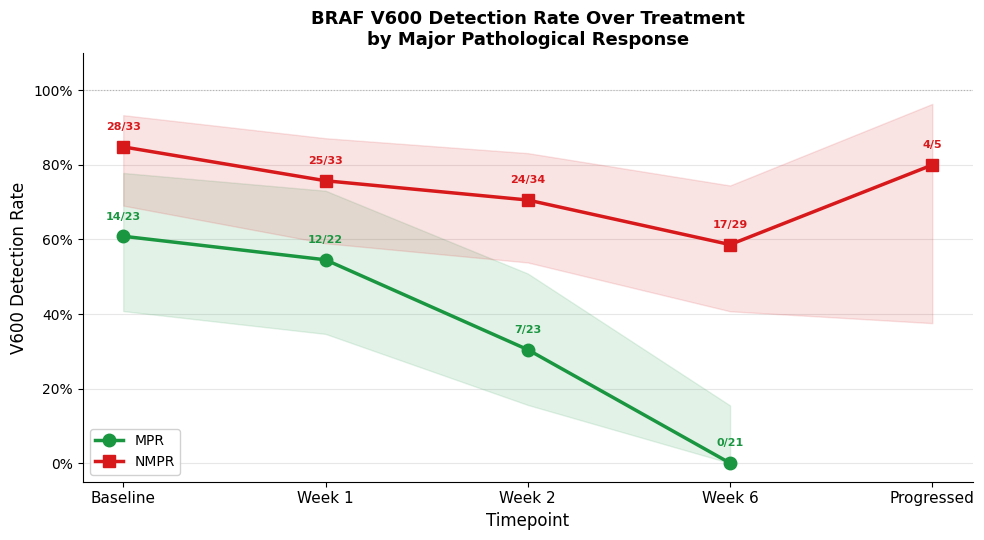

In [109]:

# --- Prep data ---
plot_df = rna.copy()
plot_df = plot_df[plot_df['TIMEPOINT'] != 'Unknown']

# Merge MPR status
plot_df = plot_df.merge(
    patient_meta[['MPR']].reset_index().rename(columns={'MelPin': 'PATIENT'}),
    on='PATIENT',
    how='left'
)

plot_df = plot_df [[c for c in plot_df.columns if not c.endswith(("_x", "_y"))]]

# Flag V600-positive (E, K, or R)
plot_df['V600_positive'] = plot_df['V600_TYPE'].isin(['V600E', 'V600K', 'V600R'])

print(plot_df)
# Only keep patients with known MPR status
plot_df['MPR_group'] = plot_df['Response'].map({
    'pCR': 'MPR', 'npCR': 'MPR',
    'pPR': 'NMPR', 'pNR': 'NMPR'
})
plot_df = plot_df[plot_df['MPR_group'].isin(['MPR', 'NMPR'])]

tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']

# Calculate detection rate per timepoint per response group
rates = []
for mpr in ['MPR', 'NMPR']:
    for tp in tp_order:
        sub = plot_df[(plot_df['MPR_group'] == mpr) & (plot_df['TIMEPOINT'] == tp)]
        n_total = len(sub)
        if n_total == 0:
            continue
        n_pos = sub['V600_positive'].sum()
        rate = n_pos / n_total
        # Wilson confidence interval
        z = 1.96
        denom = 1 + z**2 / n_total
        centre = (rate + z**2 / (2 * n_total)) / denom
        margin = z * np.sqrt((rate * (1 - rate) + z**2 / (4 * n_total)) / n_total) / denom
        rates.append({
            'MPR': mpr,
            'TIMEPOINT': tp,
            'rate': rate,
            'ci_low': max(0, centre - margin),
            'ci_high': min(1, centre + margin),
            'n_pos': int(n_pos),
            'n_total': int(n_total),
        })

rates_df = pd.DataFrame(rates)
print(rates_df)
rates_df['TIMEPOINT'] = pd.Categorical(rates_df['TIMEPOINT'], categories=tp_order, ordered=True)
rates_df = rates_df.sort_values('TIMEPOINT')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5.5))

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}
markers = {'MPR': 'o', 'NMPR': 's'}
labels = {'MPR': 'MPR', 'NMPR': 'NMPR'}

for mpr in ['MPR', 'NMPR']:
    sub = rates_df[rates_df['MPR'] == mpr]
    x = np.arange(len(sub))
    ax.plot(x, sub['rate'].values, marker=markers[mpr], color=colors[mpr],
            linewidth=2.5, markersize=9, label=labels[mpr], zorder=3)
    ax.fill_between(x, sub['ci_low'].values, sub['ci_high'].values,
                    color=colors[mpr], alpha=0.12, zorder=2)
    # Annotate n/N
    for xi, row in zip(x, sub.itertuples()):
        ax.annotate(f'{row.n_pos}/{row.n_total}',
                    (xi, row.rate), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=8, color=colors[mpr],
                    fontweight='bold')

ax.set_xticks(np.arange(len(tp_order)))
ax.set_xticklabels(tp_order, fontsize=11)
ax.set_ylabel('V600 Detection Rate', fontsize=12)
ax.set_xlabel('Timepoint', fontsize=12)
ax.set_title('BRAF V600 Detection Rate Over Treatment\nby Major Pathological Response',
             fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('v600_detection_rate_by_response.png', dpi=300, bbox_inches='tight')
plt.show()

## Detection via Treatment Arm

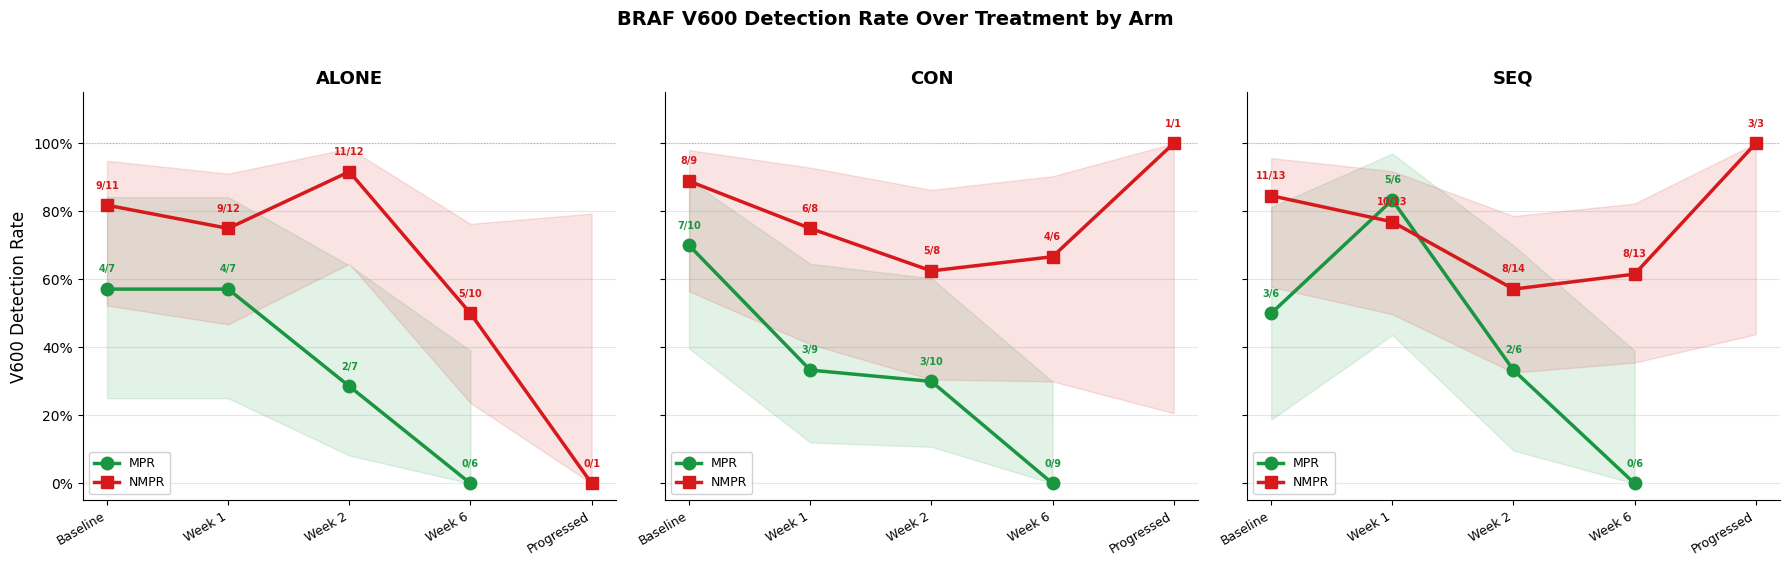

In [110]:
tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
arms = sorted(plot_df['ARM'].dropna().unique())

# --- Calculate new rates ---
rates = []
for arm in arms:
    for mpr in ['MPR', 'NMPR']:
        for tp in tp_order:
            sub = plot_df[
                (plot_df['ARM'] == arm) &
                (plot_df['MPR_group'] == mpr) &
                (plot_df['TIMEPOINT'] == tp)
            ]
            n_total = len(sub)
            if n_total == 0:
                continue
            n_pos = sub['V600_positive'].sum()
            rate = n_pos / n_total
            z = 1.96
            denom = 1 + z**2 / n_total
            centre = (rate + z**2 / (2 * n_total)) / denom
            margin = z * np.sqrt((rate * (1 - rate) + z**2 / (4 * n_total)) / n_total) / denom
            rates.append({
                'ARM': arm,
                'MPR': mpr,
                'TIMEPOINT': tp,
                'rate': rate,
                'ci_low': max(0, centre - margin),
                'ci_high': min(1, centre + margin),
                'n_pos': int(n_pos),
                'n_total': int(n_total),
            })

rates_df = pd.DataFrame(rates)
rates_df['TIMEPOINT'] = pd.Categorical(rates_df['TIMEPOINT'], categories=tp_order, ordered=True)
rates_df = rates_df.sort_values('TIMEPOINT')

# --- Faceted plot ---
n_arms = len(arms)
fig, axes = plt.subplots(1, n_arms, figsize=(6 * n_arms, 5.5), sharey=True)
if n_arms == 1:
    axes = [axes]

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}
markers = {'MPR': 'o', 'NMPR': 's'}
labels = {'MPR': 'MPR', 'NMPR': 'NMPR'}

for ax, arm in zip(axes, arms):
    arm_data = rates_df[rates_df['ARM'] == arm]

    for mpr in ['MPR', 'NMPR']:
        sub = arm_data[arm_data['MPR'] == mpr].sort_values('TIMEPOINT')
        if sub.empty:
            continue
        x = np.arange(len(sub))
        ax.plot(x, sub['rate'].values, marker=markers[mpr], color=colors[mpr],
                linewidth=2.5, markersize=9, label=labels[mpr], zorder=3)
        ax.fill_between(x, sub['ci_low'].values, sub['ci_high'].values,
                        color=colors[mpr], alpha=0.12, zorder=2)
        for xi, row in zip(x, sub.itertuples()):
            ax.annotate(f'{row.n_pos}/{row.n_total}',
                        (xi, row.rate), textcoords='offset points',
                        xytext=(0, 12), ha='center', fontsize=7, color=colors[mpr],
                        fontweight='bold')

    ax.set_xticks(np.arange(len(tp_order)))
    ax.set_xticklabels(tp_order, fontsize=9, rotation=30, ha='right')
    ax.set_title(f'{arm}', fontsize=13, fontweight='bold')
    ax.set_ylim(-0.05, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='lower left', fontsize=9, framealpha=0.9)

axes[0].set_ylabel('V600 Detection Rate', fontsize=12)

fig.suptitle('BRAF V600 Detection Rate Over Treatment by Arm',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('v600_detection_rate_by_arm.png', dpi=300, bbox_inches='tight')
plt.show()

## RNA VAF vs DNA VAF

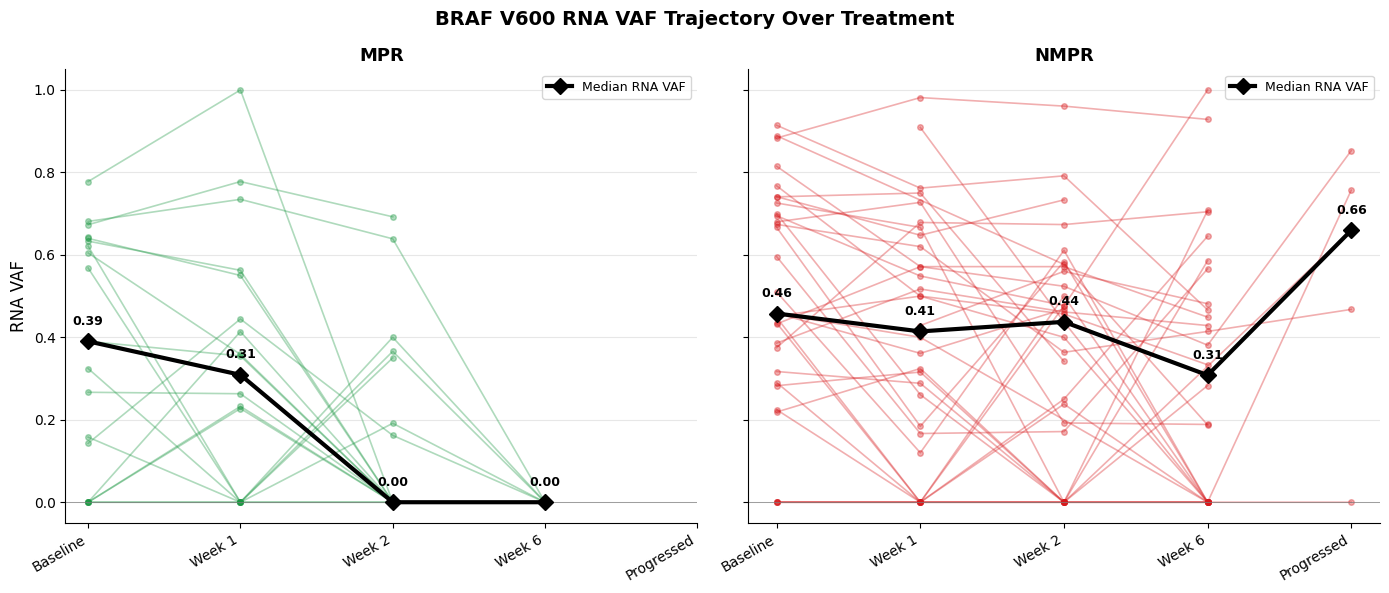

In [111]:
# Only patients with at least one V600-positive timepoint
v600_patients = plot_df[plot_df['V600_TYPE'] != 'WT']['PATIENT'].unique()
plot_df = plot_df[plot_df['PATIENT'].isin(v600_patients)]

tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
tp_to_x = {tp: i for i, tp in enumerate(tp_order)}
plot_df['x'] = plot_df['TIMEPOINT'].map(tp_to_x)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}

for ax, mpr, title in zip(axes, ['MPR', 'NMPR'],
                            ['MPR', 'NMPR']):
    sub = plot_df[plot_df['MPR_group'] == mpr]

    for patient, pdata in sub.groupby('PATIENT'):
        pdata = pdata.sort_values('x')
        ax.plot(pdata['x'], pdata['VAF'],
                marker='o', markersize=4, linewidth=1.2,
                alpha=0.35, color=colors[mpr], zorder=2)

    # Group median RNA VAF per timepoint
    medians = sub.groupby('x')['VAF'].median()
    ax.plot(medians.index, medians.values, color='black', linewidth=3,
            marker='D', markersize=8, zorder=5, label='Median RNA VAF')

    # Annotate median values
    for xi, med in medians.items():
        ax.annotate(f'{med:.2f}', (xi, med), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(tp_order)))
    ax.set_xticklabels(tp_order, fontsize=10, rotation=30, ha='right')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_ylabel('RNA VAF', fontsize=12)

fig.suptitle('BRAF V600 RNA VAF Trajectory Over Treatment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('v600_rna_vaf_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

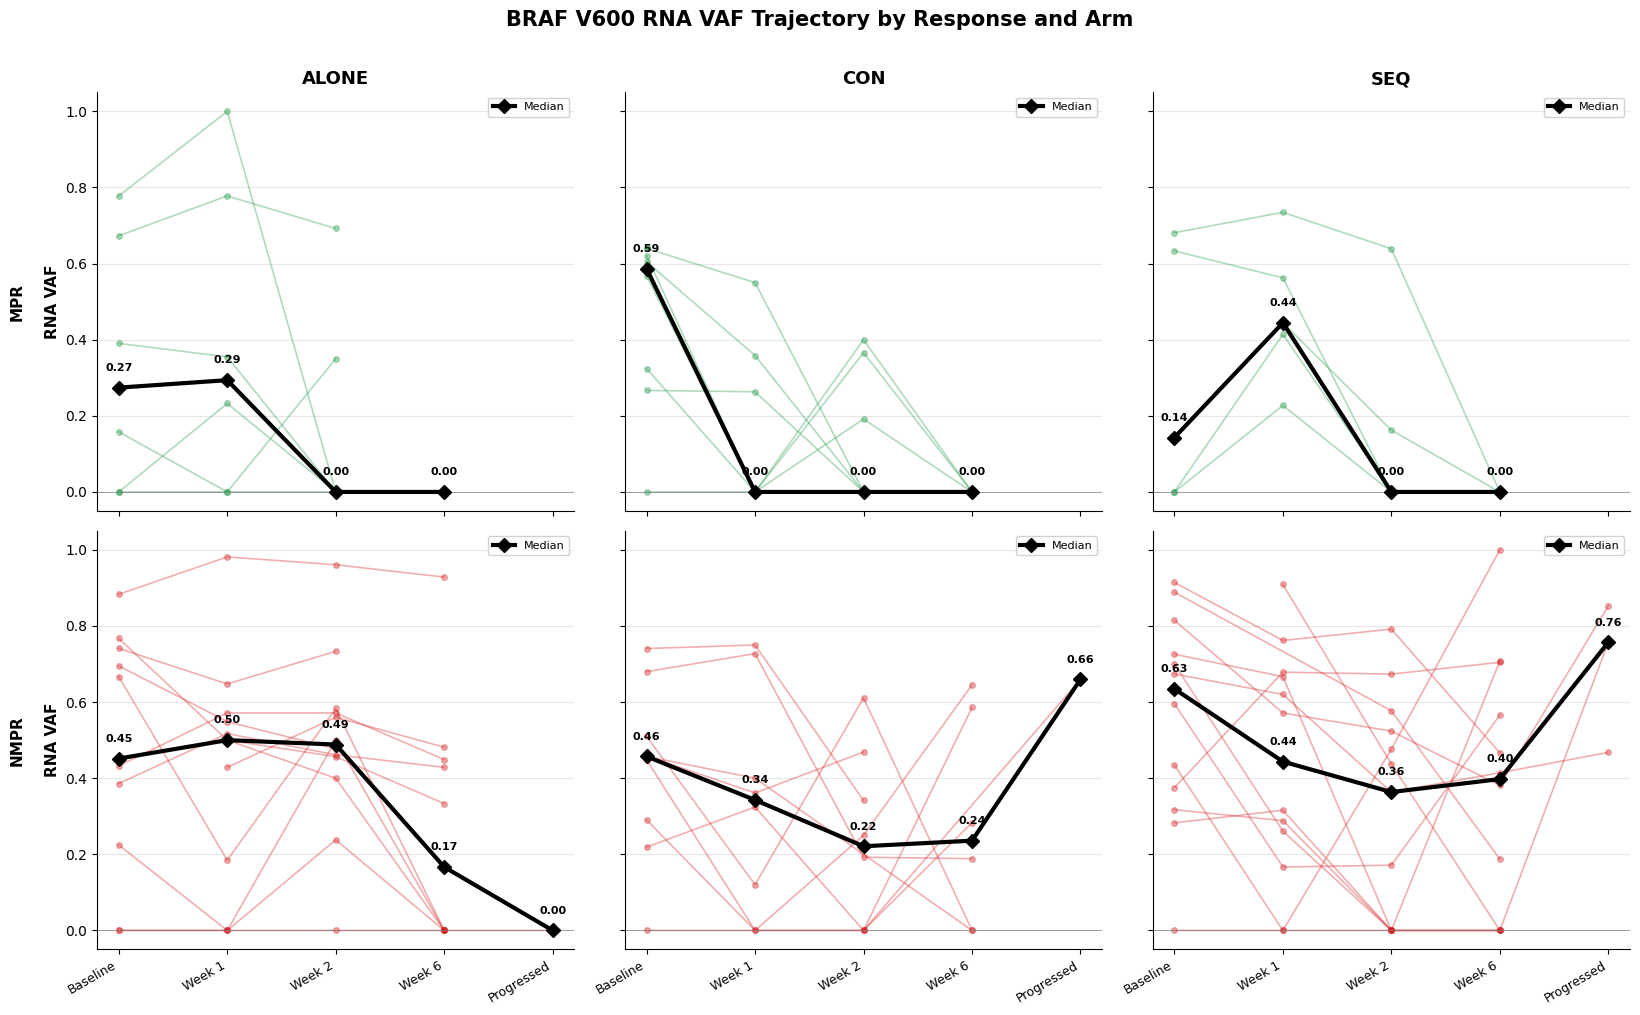

In [112]:

v600_patients = plot_df[plot_df['V600_TYPE'] != 'WT']['PATIENT'].unique()
plot_df_sub = plot_df[plot_df['PATIENT'].isin(v600_patients)]

tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
tp_to_x = {tp: i for i, tp in enumerate(tp_order)}
plot_df_sub['x'] = plot_df_sub['TIMEPOINT'].map(tp_to_x)

arms = sorted(plot_df_sub['ARM'].dropna().unique())
responses = ['MPR', 'NMPR']
colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}

# --- Plot: Response (rows) x Arms (columns) ---
n_arms = len(arms)
fig, axes = plt.subplots(2, n_arms, figsize=(5.5 * n_arms, 10), sharey=True, sharex=True)
if n_arms == 1:
    axes = axes.reshape(-1, 1)

for row, mpr in enumerate(responses):
    for col, arm in enumerate(arms):
        ax = axes[row, col]
        sub = plot_df_sub[(plot_df_sub['ARM'] == arm) & (plot_df_sub['MPR_group'] == mpr)]

        n_patients = sub['PATIENT'].nunique()

        for patient, pdata in sub.groupby('PATIENT'):
            pdata = pdata.sort_values('x')
            ax.plot(pdata['x'], pdata['VAF'],
                    marker='o', markersize=4, linewidth=1.2,
                    alpha=0.35, color=colors[mpr], zorder=2)

        if not sub.empty:
            medians = sub.groupby('x')['VAF'].median()
            ax.plot(medians.index, medians.values, color='black', linewidth=3,
                    marker='D', markersize=7, zorder=5, label='Median')
            for xi, med in medians.items():
                ax.annotate(f'{med:.2f}', (xi, med), textcoords='offset points',
                            xytext=(0, 12), ha='center', fontsize=8, fontweight='bold')

        ax.set_ylim(-0.05, 1.05)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(0, color='grey', linewidth=0.5)

        # Arm label on top row only
        if row == 0:
            ax.set_title(arm, fontsize=13, fontweight='bold')

        # Response label on left column
        if col == 0:
            ax.set_ylabel(f'{mpr}\n\nRNA VAF', fontsize=11, fontweight='bold')

        ax.text(0.98, 0.98, f'n={n_patients}', transform=ax.transAxes,
                ha='right', va='top', fontsize=10, color='grey')

        # x labels on bottom row only
        if row == 1:
            ax.set_xticks(range(len(tp_order)))
            ax.set_xticklabels(tp_order, fontsize=9, rotation=30, ha='right')
        else:
            ax.set_xticks(range(len(tp_order)))
            ax.set_xticklabels([])

        if not sub.empty:
            ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

fig.suptitle('BRAF V600 RNA VAF Trajectory by Response and Arm',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('v600_rna_vaf_trajectory_response_arm.png', dpi=300, bbox_inches='tight')
plt.show()

## Statistical Testing: VAF Trajectories

Mixed-effects model (patient as random intercept) and paired Wilcoxon tests
to formally assess whether RNA VAF changes over treatment differ by response group.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from itertools import combinations
import statsmodels.formula.api as smf
import statsmodels.api as sm
HAS_STATSMODELS = True

In [114]:
# ---------------------------------------------------------------
# Prepare modelling dataframe from plot_df (V600+ patients only)
# ---------------------------------------------------------------

tp_order = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

model_df = plot_df.copy()
model_df = model_df[model_df["TIMEPOINT"].isin(tp_order)]
model_df = model_df[model_df["MPR_group"].isin(["MPR", "NMPR"])]
model_df = model_df.dropna(subset=["VAF", "PATIENT", "TIMEPOINT", "MPR_group"])

# Numeric timepoint for the linear model (weeks since baseline)
tp_weeks = {"Baseline": 0, "Week 1": 1, "Week 2": 2, "Week 6": 6, "Progressed": 12}
model_df["weeks"] = model_df["TIMEPOINT"].map(tp_weeks)

# Ensure types
model_df["PATIENT"] = model_df["PATIENT"].astype(str)
model_df["MPR_group"] = model_df["MPR_group"].astype(str)

print(f"Modelling dataframe: {len(model_df)} observations, "
      f"{model_df['PATIENT'].nunique()} patients")
print(f"MPR: {(model_df['MPR_group']=='MPR').sum()} obs, "
      f"NMPR: {(model_df['MPR_group']=='NMPR').sum()} obs")
print()
print(model_df.groupby(["MPR_group", "TIMEPOINT"]).agg(
    n_obs=("VAF", "count"),
    median_VAF=("VAF", "median"),
    mean_VAF=("VAF", "mean"),
    sd_VAF=("VAF", "std")
).round(3))


Modelling dataframe: 200 observations, 53 patients
MPR: 70 obs, NMPR: 130 obs

                      n_obs  median_VAF  mean_VAF  sd_VAF
MPR_group TIMEPOINT                                      
MPR       Baseline       19       0.390     0.375   0.291
          Week 1         18       0.309     0.329   0.308
          Week 2         18       0.000     0.156   0.234
          Week 6         15       0.000     0.000   0.000
          Progressed      0         NaN       NaN     NaN
NMPR      Baseline       32       0.458     0.493   0.273
          Week 1         32       0.414     0.400   0.294
          Week 2         33       0.438     0.358   0.274
          Week 6         28       0.308     0.313   0.311
          Progressed      5       0.660     0.547   0.338


### 1. Linear Mixed-Effects Model

VAF ~ weeks * MPR_group + (1 | PATIENT)

Tests whether:
- VAF changes over time (weeks)
- MPR vs NMPR differ in baseline VAF (MPR_group)
- **The rate of VAF change differs by response (weeks × MPR_group interaction)**

In [115]:
model_df

,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,VAF,REF_READS,ALT_READS,DP,QUAL,FILTER,POS,Response,AnyResponse,ARM,status,V600_positive,MPR_group,x,weeks
0,16518,Baseline,A,T,V600E,0.218750,25.0,7.0,32.0,133.64,PASS,140753336.0,pNR,Non-responder,CON,2,True,NMPR,0,0
1,18369,Baseline,A,T,V600E,0.604651,17.0,26.0,43.0,744.64,PASS,140753336.0,pCR,Responder,CON,2,True,MPR,0,0
2,24799,Baseline,A,T,V600E,0.458333,26.0,22.0,48.0,519.64,PASS,140753336.0,pNR,Non-responder,CON,2,True,NMPR,0,0
3,28248,Baseline,A,T,V600E,0.814815,5.0,22.0,27.0,619.64,PASS,140753336.0,pNR,Non-responder,SEQ,2,True,NMPR,0,0
4,36029,Baseline,A,T,V600E,0.266667,22.0,8.0,30.0,179.64,PASS,140753336.0,pCR,Responder,CON,2,True,MPR,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,28248,Progressed,A,T,V600E,0.852941,5.0,29.0,34.0,920.64,PASS,140753336.0,pNR,Non-responder,SEQ,2,True,NMPR,4,12
219,43463,Progressed,A,T,V600E,0.467742,33.0,29.0,62.0,946.64,PASS,140753336.0,pNR,Non-responder,SEQ,2,True,NMPR,4,12
220,51685,Progressed,AC,TT,V600K,0.659574,16.0,31.0,47.0,1246.64,PASS,140753336.0,pPR,Responder,CON,3,True,NMPR,4,12
221,53620,Progressed,None,None,WT,0.000000,NaN,NaN,NaN,NaN,None,NaN,pPR,Responder,ALONE,1,False,NMPR,4,12


In [116]:
# ---------------------------------------------------------------
# Mixed-effects model: VAF ~ weeks * MPR_group + (1 | PATIENT)
# ---------------------------------------------------------------
# Note: If the random intercept variance is near zero, the Hessian
# can be singular. Here I am trying multiple optimisers and fall back to OLS
# with clustered standard errors if the mixed model fails.

model_converged = False

# Try mixed model with several optimisers
for method in ["lbfgs", "powell", "cg", "nm"]:
    try:
        md = smf.mixedlm(
            "VAF ~ weeks * MPR_group",
            data=model_df,
            groups=model_df["PATIENT"],
        )
        mdf = md.fit(reml=True, method=method)
        model_converged = True
        print(f"Mixed model converged with method: {method}")
        break
    except Exception as e:
        print(f"Method {method} failed: {type(e).__name__}")
        continue

# Fallback: OLS with cluster-robust SEs if mixed model fails
if not model_converged:
    print()
    print("Mixed model failed — falling back to OLS with cluster-robust SEs")
    print("(This accounts for within-patient correlation via Huber-White SEs)")
    print()
    ols = smf.ols("VAF ~ weeks * MPR_group", data=model_df).fit(
        cov_type="cluster", cov_kwds={"groups": model_df["PATIENT"]}
    )
    mdf = ols  # use same variable name so downstream code works

print()
print(mdf.summary())
print()

# Extract key results
print("=" * 60)
print("KEY RESULTS")
print("=" * 60)
for term in mdf.fe_params.index if hasattr(mdf, "fe_params") else mdf.params.index:
    params = mdf.fe_params if hasattr(mdf, "fe_params") else mdf.params
    coef = params[term]
    pval = mdf.pvalues[term]
    ci = mdf.conf_int().loc[term]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {term:35s}  coef={coef:+.4f}  p={pval:.4f} {sig}  95%CI [{ci.iloc[0]:.4f}, {ci.iloc[1]:.4f}]")

print()
print("Interpretation:")
print("  - Intercept: mean VAF at baseline for reference group (MPR)")
print("  - weeks: VAF change per week in MPR patients")
print("  - MPR_group[T.NMPR]: baseline VAF difference (NMPR vs MPR)")
print("  - weeks:MPR_group[T.NMPR]: DIFFERENCE in VAF slope (NMPR vs MPR)")
print("    → If significant, response groups have different VAF trajectories")

Method lbfgs failed: LinAlgError
Method powell failed: LinAlgError
Method cg failed: LinAlgError
Method nm failed: LinAlgError

Mixed model failed — falling back to OLS with cluster-robust SEs
(This accounts for within-patient correlation via Huber-White SEs)


                            OLS Regression Results                            
Dep. Variable:                    VAF   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     24.27
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.15e-15
Time:                        15:19:10   Log-Likelihood:                -21.569
No. Observations:                 200   AIC:                             61.14
Df Residuals:                     191   BIC:                             90.82
Df Model:                           8                                         
Covariance Type:           

### 2. Paired Wilcoxon Signed-Rank Tests

Within each response group, test whether VAF changes significantly
between consecutive timepoints (paired by patient).

In [117]:
# ---------------------------------------------------------------
# Paired Wilcoxon signed-rank tests: consecutive timepoints
# ---------------------------------------------------------------

tp_pairs = [
    ("Baseline", "Week 1"),
    ("Baseline", "Week 2"),
    ("Baseline", "Week 6"),
    ("Week 1", "Week 2"),
    ("Week 2", "Week 6"),
]

wilcox_results = []

for mpr_grp in ["MPR", "NMPR"]:
    grp = model_df[model_df["MPR_group"] == mpr_grp]
    
    for tp1, tp2 in tp_pairs:
        # Pivot to get paired values
        paired = grp.pivot_table(index="PATIENT", columns="TIMEPOINT", values="VAF")
        
        if tp1 not in paired.columns or tp2 not in paired.columns:
            continue
        
        pair = paired[[tp1, tp2]].dropna()
        n_pairs = len(pair)
        
        if n_pairs < 3:
            continue
        
        diff = pair[tp2] - pair[tp1]
        median_diff = diff.median()
        
        try:
            stat, pval = stats.wilcoxon(pair[tp1], pair[tp2], alternative="two-sided")
        except ValueError:
            # All differences are zero
            stat, pval = 0, 1.0
        
        wilcox_results.append({
            "Group": mpr_grp,
            "Comparison": f"{tp1} → {tp2}",
            "n_pairs": n_pairs,
            "median_VAF_t1": pair[tp1].median(),
            "median_VAF_t2": pair[tp2].median(),
            "median_diff": median_diff,
            "W_stat": stat,
            "p_value": pval,
        })

wilcox_df = pd.DataFrame(wilcox_results)

# Bonferroni correction within each group
for grp in ["MPR", "NMPR"]:
    mask = wilcox_df["Group"] == grp
    n_tests = mask.sum()
    wilcox_df.loc[mask, "p_adjusted"] = (wilcox_df.loc[mask, "p_value"] * n_tests).clip(upper=1.0)

wilcox_df["sig"] = wilcox_df["p_adjusted"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

print("Paired Wilcoxon signed-rank tests (Bonferroni-corrected)")
print("=" * 90)
print(wilcox_df.to_string(index=False, float_format="%.4f"))


Paired Wilcoxon signed-rank tests (Bonferroni-corrected)
Group        Comparison  n_pairs  median_VAF_t1  median_VAF_t2  median_diff   W_stat  p_value  p_adjusted sig
  MPR Baseline → Week 1       18         0.3573         0.3090      -0.0018  62.0000   0.7564      1.0000    
  MPR Baseline → Week 2       18         0.3573         0.0000      -0.1630  19.0000   0.0199      0.0994    
  MPR Baseline → Week 6       15         0.3902         0.0000      -0.3902   0.0000   0.0033      0.0167   *
  MPR   Week 1 → Week 2       18         0.3090         0.0000      -0.2299  34.0000   0.0787      0.3937    
  MPR   Week 2 → Week 6       15         0.0000         0.0000       0.0000   0.0000   0.0431      0.2156    
 NMPR Baseline → Week 1       30         0.4577         0.3806      -0.0581  84.0000   0.0116      0.0582    
 NMPR Baseline → Week 2       31         0.4583         0.4000      -0.2180 118.0000   0.0185      0.0926    
 NMPR Baseline → Week 6       26         0.4544         0.3082 

### 3. Between-Group Comparison (Mann-Whitney U)

At each timepoint, test whether VAF differs between MPR and NMPR.

In [118]:
# ---------------------------------------------------------------
# Mann-Whitney U: MPR vs NMPR at each timepoint
# ---------------------------------------------------------------

mw_results = []

for tp in tp_order:
    mpr_vals = model_df[(model_df["MPR_group"] == "MPR") & (model_df["TIMEPOINT"] == tp)]["VAF"]
    nmpr_vals = model_df[(model_df["MPR_group"] == "NMPR") & (model_df["TIMEPOINT"] == tp)]["VAF"]
    
    if len(mpr_vals) < 2 or len(nmpr_vals) < 2:
        continue
    
    stat, pval = stats.mannwhitneyu(mpr_vals, nmpr_vals, alternative="two-sided")
    
    # Rank-biserial effect size: r = 1 - 2U / (n1*n2)
    n1, n2 = len(mpr_vals), len(nmpr_vals)
    r_effect = 1 - (2 * stat) / (n1 * n2)
    
    mw_results.append({
        "Timepoint": tp,
        "n_MPR": n1,
        "n_NMPR": n2,
        "median_MPR": mpr_vals.median(),
        "median_NMPR": nmpr_vals.median(),
        "U_stat": stat,
        "p_value": pval,
        "rank_biserial_r": r_effect,
    })

mw_df = pd.DataFrame(mw_results)
n_tests = len(mw_df)
mw_df["p_adjusted"] = (mw_df["p_value"] * n_tests).clip(upper=1.0)
mw_df["sig"] = mw_df["p_adjusted"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

print("Mann-Whitney U: MPR vs NMPR at each timepoint (Bonferroni-corrected)")
print("=" * 95)
print(mw_df.to_string(index=False, float_format="%.4f"))


Mann-Whitney U: MPR vs NMPR at each timepoint (Bonferroni-corrected)
Timepoint  n_MPR  n_NMPR  median_MPR  median_NMPR   U_stat  p_value  rank_biserial_r  p_adjusted sig
 Baseline     19      32      0.3902       0.4577 227.0000   0.1351           0.2533      0.5402    
   Week 1     18      32      0.3090       0.4143 245.0000   0.3861           0.1493      1.0000    
   Week 2     18      33      0.0000       0.4375 172.0000   0.0114           0.4209      0.0454   *
   Week 6     15      28      0.0000       0.3082  82.5000   0.0002           0.6071      0.0010 ***


### 4. Visualisation: Mixed-Effects Coefficients + Pairwise Test Summary

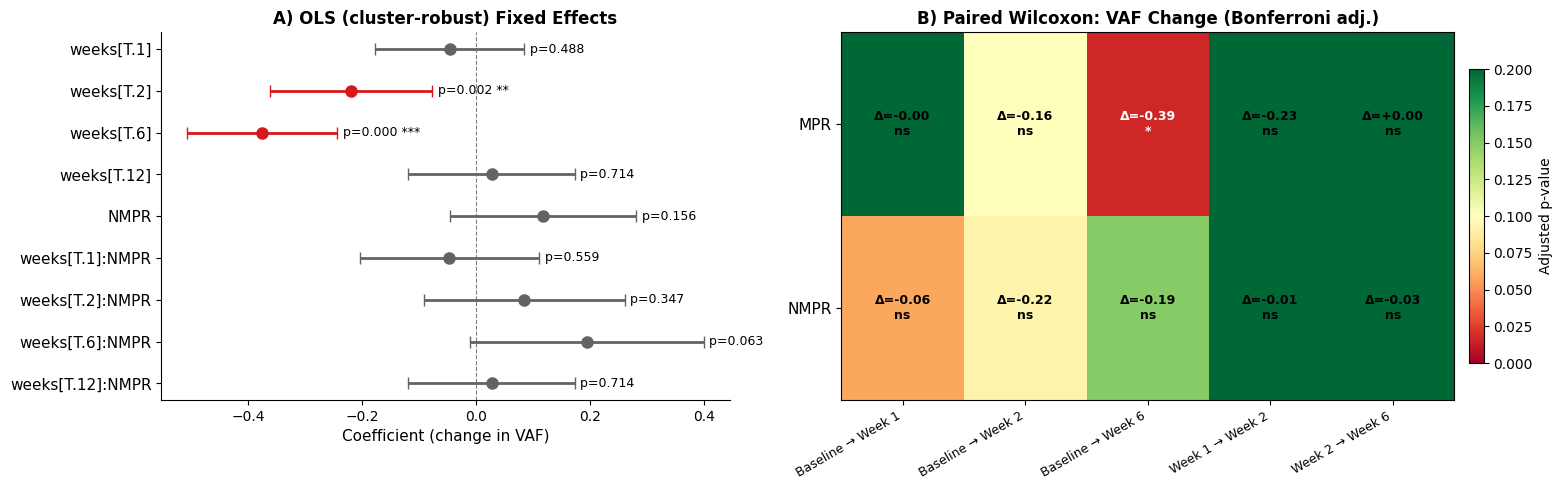

In [119]:
# ---------------------------------------------------------------
# Figure: Forest plot of model coefficients + 
#         VAF change significance heatmap
# ---------------------------------------------------------------

# Handle both mixed model and OLS objects
if hasattr(mdf, "fe_params"):
    _params = mdf.fe_params
    _pvals = mdf.pvalues
    _ci = mdf.conf_int()
else:
    _params = mdf.params
    _pvals = mdf.pvalues
    _ci = mdf.conf_int()

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={"width_ratios": [1, 1.3]})

# --- Panel A: Forest plot of fixed effects ---
ax = axes[0]
terms = [t for t in _params.index if t != "Intercept"]
coefs = [_params[t] for t in terms]
ci = _ci.loc[terms]
pvals = [_pvals[t] for t in terms]

y_pos = range(len(terms))
colors_forest = ["#d7191c" if p < 0.05 else "#636363" for p in pvals]

ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
for i, (term, coef) in enumerate(zip(terms, coefs)):
    ci_low, ci_high = ci.iloc[i, 0], ci.iloc[i, 1]
    ax.errorbar(coef, i, xerr=[[coef - ci_low], [ci_high - coef]],
               fmt="o", color=colors_forest[i], capsize=4, markersize=8, linewidth=2)
    p = pvals[i]
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    ax.text(ci_high + 0.01, i, f"p={p:.3f} {sig}", va="center", fontsize=9)

# Clean up term labels
labels = [t.replace("MPR_group[T.NMPR]", "NMPR")
           .replace("weeks:MPR_group[T.NMPR]", "weeks × NMPR")
          for t in terms]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Coefficient (change in VAF)", fontsize=11)
model_type = "Mixed-Model" if hasattr(mdf, "fe_params") else "OLS (cluster-robust)"
ax.set_title(f"A) {model_type} Fixed Effects", fontsize=12, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

# --- Panel B: Pairwise significance heatmap ---
ax = axes[1]

comparisons = wilcox_df["Comparison"].unique()
groups = ["MPR", "NMPR"]

pval_matrix = np.full((len(groups), len(comparisons)), np.nan)
diff_matrix = np.full((len(groups), len(comparisons)), np.nan)

for i, grp in enumerate(groups):
    for j, comp in enumerate(comparisons):
        row = wilcox_df[(wilcox_df["Group"] == grp) & (wilcox_df["Comparison"] == comp)]
        if not row.empty:
            pval_matrix[i, j] = row["p_adjusted"].values[0]
            diff_matrix[i, j] = row["median_diff"].values[0]

im = ax.imshow(pval_matrix, cmap="RdYlGn", vmin=0, vmax=0.2, aspect="auto")

for i in range(len(groups)):
    for j in range(len(comparisons)):
        p = pval_matrix[i, j]
        d = diff_matrix[i, j]
        if np.isnan(p):
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")
        else:
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            label = f"Δ={d:+.2f}\n{sig}"
            color = "white" if p < 0.05 else "black"
            ax.text(j, i, label, ha="center", va="center", fontsize=9, fontweight="bold", color=color)

ax.set_xticks(range(len(comparisons)))
ax.set_xticklabels(comparisons, fontsize=9, rotation=30, ha="right")
ax.set_yticks(range(len(groups)))
ax.set_yticklabels(groups, fontsize=11)
ax.set_title("B) Paired Wilcoxon: VAF Change (Bonferroni adj.)", fontsize=12, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Adjusted p-value", fontsize=10)

plt.tight_layout()
plt.savefig("vaf_statistical_tests.png", dpi=300, bbox_inches="tight")
plt.show()


## RNA VAF vs DNA VAF Concordance

Compare baseline RNA VAF against DNA VAF (from Sequenza) to assess allele-specific 
expression bias, then track how RNA VAF diverges from the DNA baseline anchor over treatment.

In [120]:
from scipy.stats import pearsonr, spearmanr

In [121]:
# ---------------------------------------------------------------
# Merge DNA VAF (baseline ground truth) into the V600+ patient df
# ---------------------------------------------------------------

# DNA VAF per patient (baseline only, from Sequenza)
dna_meta['patient_id'] = dna_meta['melpin'].str.extract(r'(\d+)').astype(int)
dna_dedup = dna_meta.drop_duplicates('patient_id').set_index('patient_id')

# Get baseline RNA VAF for V600+ patients
baseline_rna = model_df[model_df['TIMEPOINT'] == 'Baseline'][['PATIENT', 'VAF', 'MPR_group']].copy()
baseline_rna['PATIENT'] = baseline_rna['PATIENT'].astype(int)
baseline_rna = baseline_rna.merge(
    dna_dedup[['braf_v600_AF']].reset_index().rename(columns={'patient_id': 'PATIENT', 'braf_v600_AF': 'DNA_VAF'}),
    on='PATIENT', how='inner'
)
baseline_rna = baseline_rna.rename(columns={'VAF': 'RNA_VAF'})
baseline_rna = baseline_rna.dropna(subset=['RNA_VAF', 'DNA_VAF'])

print(f"Patients with matched baseline RNA + DNA VAF: {len(baseline_rna)}")
print(baseline_rna[['PATIENT', 'RNA_VAF', 'DNA_VAF', 'MPR_group']].to_string(index=False))

Patients with matched baseline RNA + DNA VAF: 51
 PATIENT  RNA_VAF  DNA_VAF MPR_group
   16518 0.218750 0.266667      NMPR
   18369 0.604651 0.411290       MPR
   24799 0.458333 0.423529      NMPR
   28248 0.814815 0.627907      NMPR
   36029 0.266667 0.000000       MPR
   37747 0.888889 0.638554      NMPR
   39330 0.883333 0.962963      NMPR
   43306 0.282609 0.166667      NMPR
   43463 0.673913 0.511111      NMPR
   45212 0.290323 0.458333      NMPR
   46898 0.000000 0.000000       MPR
   47711 0.434783 0.175258      NMPR
   48210 0.457143 0.117647      NMPR
   48234 0.385965 0.414141      NMPR
   48551 0.633333 0.678571       MPR
   49407 0.777778 0.855072       MPR
   49461 0.157895 0.000000       MPR
   49523 0.767442 0.676190      NMPR
   49782 0.224490 0.067961      NMPR
   49949 0.509804 0.533981      NMPR
   50100 0.914286 0.518072      NMPR
   50149 0.000000 0.000000       MPR
   50524 0.448276 0.250000      NMPR
   50618 0.681159 0.748299       MPR
   50861 0.432432 0.347826

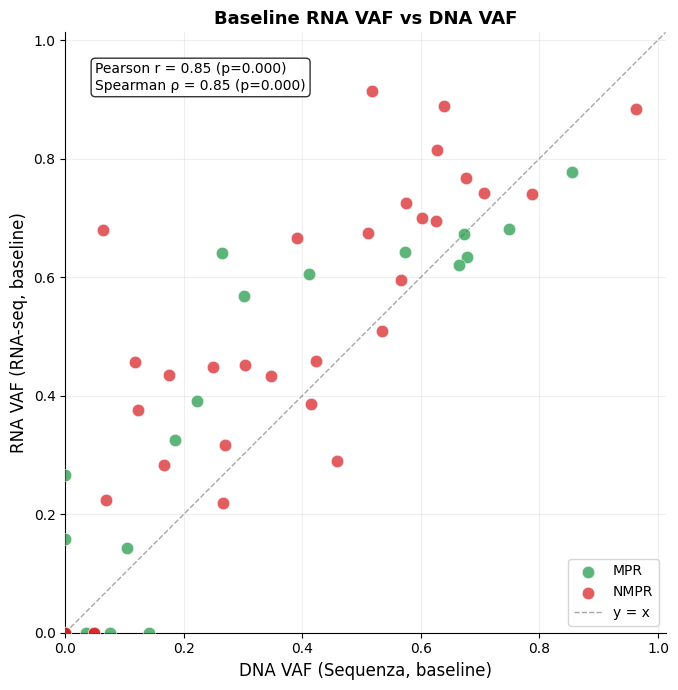


RNA - DNA VAF difference:
  Median: +0.070
  Mean:   +0.092
  → RNA VAF > DNA VAF (mutant allele overexpressed)


In [122]:
# ---------------------------------------------------------------
# Scatter: Baseline RNA VAF vs DNA VAF
# ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}

for grp in ['MPR', 'NMPR']:
    sub = baseline_rna[baseline_rna['MPR_group'] == grp]
    ax.scatter(sub['DNA_VAF'], sub['RNA_VAF'], c=colors[grp], 
               s=80, alpha=0.7, edgecolors='white', linewidth=0.5,
               label=grp, zorder=3)

# Identity line
lims = [0, max(baseline_rna[['RNA_VAF', 'DNA_VAF']].max()) + 0.05]
ax.plot(lims, lims, '--', color='grey', linewidth=1, alpha=0.7, label='y = x')

# Correlation
r_pear, p_pear = pearsonr(baseline_rna['DNA_VAF'], baseline_rna['RNA_VAF'])
r_spear, p_spear = spearmanr(baseline_rna['DNA_VAF'], baseline_rna['RNA_VAF'])
ax.text(0.05, 0.95, f"Pearson r = {r_pear:.2f} (p={p_pear:.3f})\n"
                     f"Spearman ρ = {r_spear:.2f} (p={p_spear:.3f})",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('DNA VAF (Sequenza, baseline)', fontsize=12)
ax.set_ylabel('RNA VAF (RNA-seq, baseline)', fontsize=12)
ax.set_title('Baseline RNA VAF vs DNA VAF', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('rna_vs_dna_vaf_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

# Check for systematic bias
median_diff = (baseline_rna['RNA_VAF'] - baseline_rna['DNA_VAF']).median()
mean_diff = (baseline_rna['RNA_VAF'] - baseline_rna['DNA_VAF']).mean()
print(f"\nRNA - DNA VAF difference:")
print(f"  Median: {median_diff:+.3f}")
print(f"  Mean:   {mean_diff:+.3f}")
print(f"  → {'RNA VAF > DNA VAF (mutant allele overexpressed)' 
             if mean_diff > 0 else 'RNA VAF < DNA VAF (mutant allele underexpressed)'}")


### RNA VAF Divergence from DNA VAF Over Treatment

Track (RNA VAF - DNA VAF) over timepoints, split by response. 
If responders show RNA VAF dropping *faster* than expected from tumour purity alone, 
this could suggest transcriptional suppression of the mutant allele under treatment.

In [123]:
# ---------------------------------------------------------------
# Divergence: (RNA VAF - DNA VAF) over treatment timepoints
# ---------------------------------------------------------------

# Merge DNA VAF into the full longitudinal df
divergence_df = model_df.copy()
divergence_df['PATIENT_int'] = divergence_df['PATIENT'].astype(int)
divergence_df = divergence_df.merge(
    dna_dedup[['braf_v600_AF']].reset_index().rename(
        columns={'patient_id': 'PATIENT_int', 'braf_v600_AF': 'DNA_VAF'}),
    on='PATIENT_int', how='inner'
)
divergence_df['delta_VAF'] = divergence_df['VAF'] - divergence_df['DNA_VAF']

tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
tp_to_x = {tp: i for i, tp in enumerate(tp_order)}
divergence_df['x'] = divergence_df['TIMEPOINT'].map(tp_to_x)

print(f"Patients with matched DNA VAF, RNA VAF > 0: {divergence_df['PATIENT'].nunique()}")
print(divergence_df.groupby(['MPR_group', 'TIMEPOINT'])['delta_VAF'].agg(['count', 'median', 'mean']).round(3))


Patients with matched DNA VAF, RNA VAF > 0: 53
                      count  median   mean
MPR_group TIMEPOINT                       
MPR       Baseline       19   0.001  0.063
          Week 1         18   0.043  0.031
          Week 2         18  -0.093 -0.142
          Week 6         15  -0.222 -0.298
          Progressed      0     NaN    NaN
NMPR      Baseline       32   0.088  0.110
          Week 1         32   0.000  0.013
          Week 2         33  -0.048 -0.034
          Week 6         28  -0.017 -0.052
          Progressed      5   0.155  0.112


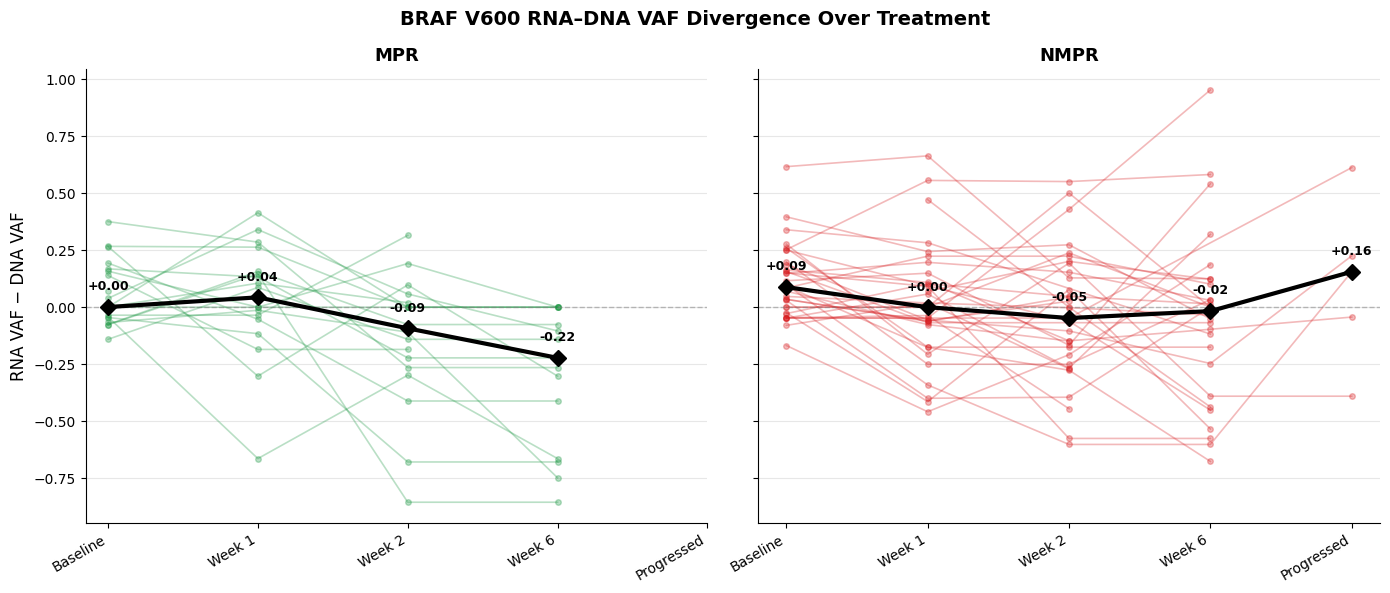

In [124]:
# ---------------------------------------------------------------
# Plot: RNA-DNA VAF divergence over treatment
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}

for ax, mpr in zip(axes, ['MPR', 'NMPR']):
    sub = divergence_df[divergence_df['MPR_group'] == mpr]

    # Individual patient traces
    for patient, pdata in sub.groupby('PATIENT'):
        pdata = pdata.sort_values('x')
        ax.plot(pdata['x'], pdata['delta_VAF'],
                marker='o', markersize=4, linewidth=1.2,
                alpha=0.3, color=colors[mpr], zorder=2)

    # Group median
    medians = sub.groupby('x')['delta_VAF'].median()
    ax.plot(medians.index, medians.values, color='black', linewidth=3,
            marker='D', markersize=8, zorder=5, label='Median')

    # Annotate
    for xi, med in medians.items():
        ax.annotate(f'{med:+.2f}', (xi, med), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

    ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(range(len(tp_order)))
    ax.set_xticklabels(tp_order, fontsize=10, rotation=30, ha='right')
    ax.set_title(mpr, fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('RNA VAF − DNA VAF', fontsize=12)

fig.suptitle('BRAF V600 RNA–DNA VAF Divergence Over Treatment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rna_dna_vaf_divergence.png', dpi=300, bbox_inches='tight')
plt.show()


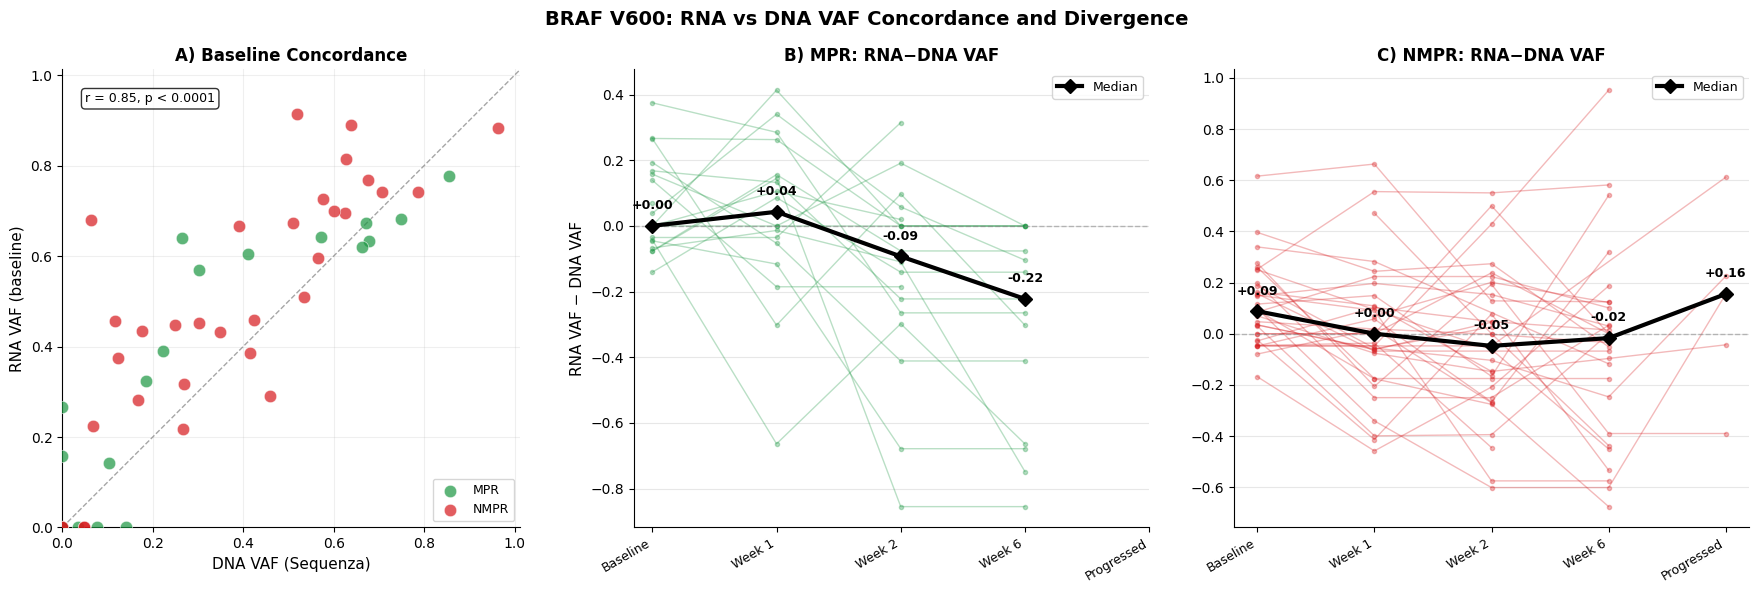

In [125]:
# ---------------------------------------------------------------
# Combined figure: Baseline concordance + Longitudinal divergence
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6), 
                          gridspec_kw={'width_ratios': [1, 1, 1]})

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}

# --- Baseline scatter ---
ax = axes[0]
for grp in ['MPR', 'NMPR']:
    sub = baseline_rna[baseline_rna['MPR_group'] == grp]
    ax.scatter(sub['DNA_VAF'], sub['RNA_VAF'], c=colors[grp],
               s=80, alpha=0.7, edgecolors='white', linewidth=0.5,
               label=grp, zorder=3)

lims = [0, max(baseline_rna[['RNA_VAF', 'DNA_VAF']].max()) + 0.05]
ax.plot(lims, lims, '--', color='grey', linewidth=1, alpha=0.7)
ax.set_xlabel('DNA VAF (Sequenza)', fontsize=11)
ax.set_ylabel('RNA VAF (baseline)', fontsize=11)
ax.set_title('A) Baseline Concordance', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

r_pear, p_pear = pearsonr(baseline_rna['DNA_VAF'], baseline_rna['RNA_VAF'])
ax.text(0.05, 0.95, f"r = {r_pear:.2f}, p < 0.0001",
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Divergence by response ---
for ax, mpr in zip(axes[1:], ['MPR', 'NMPR']):
    sub = divergence_df[divergence_df['MPR_group'] == mpr]

    for patient, pdata in sub.groupby('PATIENT'):
        pdata = pdata.sort_values('x')
        ax.plot(pdata['x'], pdata['delta_VAF'],
                marker='o', markersize=3, linewidth=1,
                alpha=0.3, color=colors[mpr], zorder=2)

    medians = sub.groupby('x')['delta_VAF'].median()
    ax.plot(medians.index, medians.values, color='black', linewidth=3,
            marker='D', markersize=7, zorder=5, label='Median')

    for xi, med in medians.items():
        ax.annotate(f'{med:+.2f}', (xi, med), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

    ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xticks(range(len(tp_order)))
    ax.set_xticklabels(tp_order, fontsize=9, rotation=30, ha='right')
    panel = 'B' if mpr == 'MPR' else 'C'
    ax.set_title(f'{panel}) {mpr}: RNA−DNA VAF', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

axes[1].set_ylabel('RNA VAF − DNA VAF', fontsize=11)

fig.suptitle('BRAF V600: RNA vs DNA VAF Concordance and Divergence',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rna_dna_vaf_combined.png', dpi=300, bbox_inches='tight')
plt.show()


The DNA VAF is only largely from baseline, so the divergence in MPR could just be reflecting that both DNA and RNA VAF are dropping with treatment (tumour clearance), but we're only subtracting the baseline DNA VAF. It's not really showing RNA diverging from DNA at the same timepoint

ideas to think about:

Option 1: Patient-specific clonal passenger panel

Intersect baseline somatic DNA calls with RNA variants Filter to diploid segments, clonal VAF, non-driver genes, >20x RNA coverage per timepoint Use median RNA VAF of these variants as per-timepoint purity estimate.

Pro: patient-specific, accounts for individual tumour content

Con: need baseline somatic calls + Sequenza segments, variant count per patient may vary, some timepoints might have poor coverage

Option 2: use the median RNA VAF of all confirmed somatic mutations

- Take every somatic variant called in baseline DNA that's detectable in RNA
- Median VAF at each timepoint = tumour content proxy
- V600 deviation from that median = interesting
- Less filtering required, more robust with larger numbers